In [104]:
%reset -f

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.style as style 
style.use('seaborn-colorblind')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from scipy import stats
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

root_dir = '/Users/weiweizhan/Desktop/Weiwei_Zhan/Projects/WUE'
os.chdir(root_dir)

pd.set_option('mode.chained_assignment', None)
plt.rcParams["legend.frameon"] = False
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['font.size'] = 11
plt.rcParams['font.family'] = 'Arial'

/var/folders/17/m2hbh37n5h71bqc9bp3sk5h00000gn/T/ipykernel_6736/113159864.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  style.use('seaborn-colorblind')


# site example for the perturbation method

## load data & model

In [2]:
sitecode    = 'US-Ho1'
target      = 'iWUE'
CO2_var     = 'CAMS_CO2'
predictors  = ['Tair','RH','SW','LAI','WS','SWC']

# full record of the site
data_full = pd.read_csv(f'./Data/site_example/{sitecode}.csv',index_col=0,parse_dates=True)

# relevant variables
var_s  = [target,'Tair','RH','VPD','SW','LAI','WS','SWC','CAMS_CO2']


# ---------------- load models ----------------
trained_model_dir = './Data/site_example/'

## with CO2
model_path_CO2 = os.path.join(trained_model_dir,target+'_'+sitecode+'_CO2.json')
model_CO2 = xgb.XGBRegressor()
model_CO2.load_model(model_path_CO2)


## Compute climatology for perturbed variables

In [3]:
def regress_line_quantile(yr_median,yr_lower,yr_upper,var,
                          ax  = None, fig = None,
                          color = 'tab:blue',xy = (0.02,0.9),
                          annotate = True,x_indent=0,
                          data_length=False):
    
    if (ax is None):
        fig,ax = plt.subplots()
        
    # remove NAN values
    x = yr_median[var].dropna().index.values
    y = yr_median[var].dropna().values
    y_low  = yr_lower[var].dropna().values  
    y_high = yr_upper[var].dropna().values 
    y_high = np.abs(y_high-y)
    y_low  = np.abs(y_low-y)
    
    # if length < 6 yr, just plot scatters, no line fitting
    x = x+x_indent # indentation of year axis
    ax.scatter(x,y,color=color)
    ax.errorbar(x, y, yerr=np.vstack([y_low, y_high]),alpha=0.7,color=color)
    length = x.shape[0]
    

    if length < 6:
        slope, intercept, r_value, p_value = np.nan, np.nan, np.nan, np.nan
    else:
        slope, intercept, r_value, p_value, _ = stats.linregress(x, y)
        
        # plot the fitted line
        line  = np.linspace(min(x), max(x), 100)
        y_pre = line*slope+intercept
        ax.plot(line, y_pre,'-',color=color,linewidth=2.5)
        
        # annotation
        anno_str = '\n$slope=$'+'${:.2g}$'.format(slope)
        if p_value < 0.05:
            anno_str += ' $p<0.05$'
        else:
            anno_str += ' $p=$'+'${:.2g}$'.format(p_value)
        
        if annotate:
            ax.annotate(anno_str,xy=xy, color=color, xycoords='axes fraction')
    
    ax.set_ylabel(var)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # return stats 
    if data_length:
        stat = [slope, intercept, r_value, p_value,length]
    else:
        stat = [slope, intercept, r_value, p_value]
        
    
    return stat


In [4]:
def check_trend_wholeyear(data_original,var,fig,ax,color,data_length=False):
    
    data = data_original.copy()
    data['DOY']       = data.index.dayofyear
    data['Year']      = data.index.year
    data['Year_deci'] = data['DOY']/365.25 + data['Year']

    yr_median = data.groupby('Year').median()
    yr_upper  = data.groupby('Year').quantile(.75)
    yr_lower  = data.groupby('Year').quantile(.25)
    
    ax.scatter(data['Year_deci'],data[var],color='darkgrey',alpha=0.4,s=20)
    
    # annual-scale fitting
    # stat: slope, intercept, r_value, p_value
    stat = regress_line_quantile(yr_median,yr_lower,yr_upper,
                                 var=var,color=color,
                                 fig=fig,ax=ax,x_indent=0.5,
                                 data_length=data_length)
        
    return stat


def get_climatology_and_trend(data_original,var,slope,intercept):
    
    data = data_original.copy()
    data['DOY']       = data.index.dayofyear
    data['Year']     = data.index.year
    data['Year_deci']= data['DOY']/365.25 + data['Year']

    # climatology & climatology+trend
    # zero-centered climatology 
    zero_center      = data[['DOY',var]]
    # zero_center[var] = zero_center[var] - zero_center[var].mean() 
    var_cmt = zero_center.groupby('DOY').mean() 
    var_cmt = var_cmt - zero_center[var].mean()
    var_cmt = var_cmt.rename(columns={var:var+'_cmt_zerocenter'})
    
    # long-term trend
    data[var+'_trend'] = data['Year_deci']*slope+intercept

    # combine zero-centered climatology & long-term trend
    var_cmt = pd.merge(data[['DOY','Year_deci',var,var+'_trend']],var_cmt[[var+'_cmt_zerocenter']],
                       how='left',left_on='DOY',right_index=True)
    
    # final climatology: zero-centered climatology + initial level
    var_cmt[var+'_cmt']      = var_cmt[var+'_cmt_zerocenter'] + var_cmt[var+'_trend'][0]
    # withtrend: zero-centered climatology + long-term trend
    var_cmt[var+'_withtrend'] = var_cmt[var+'_cmt_zerocenter'] + var_cmt[var+'_trend']

    return var_cmt


def plot_climatology(var,var_cmt,ax,plot_trend=True):
    
    ax.plot(var_cmt['Year_deci'],var_cmt[var],
        color='gray',alpha=0.6,label='original')
    if plot_trend:
        ax.plot(var_cmt['Year_deci'],var_cmt[var+'_trend'],
                color='black',label='trend',linewidth=2)


    ax.plot(var_cmt['Year_deci'],var_cmt[var+'_cmt'],color='tab:blue',
            linestyle='-',label='climatology',linewidth=1.5,marker='.',markersize=5)

    ax.set_ylabel(var)
    
    ax.legend(ncols=2)

In [5]:
color_dic = {'Tair':'tab:red','RH':'tab:blue','VPD':'#F0B400',
             'SW':'tab:orange','LAI':'tab:green',
             'SWC':'tab:brown','CAMS_CO2':'tab:cyan'}

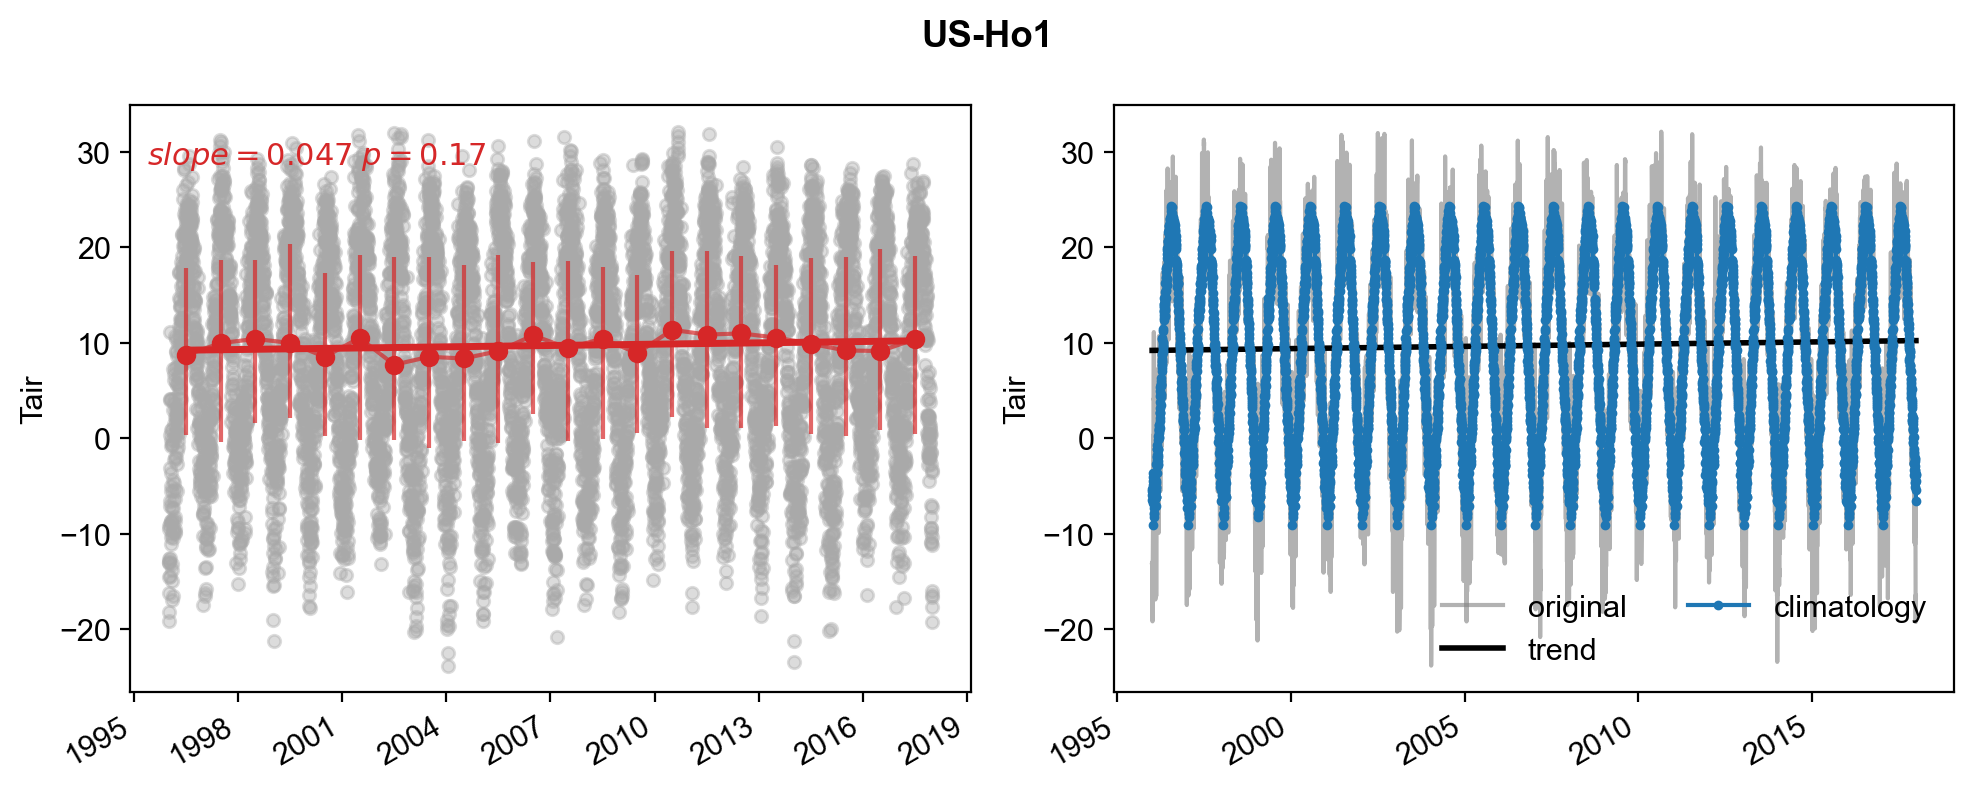

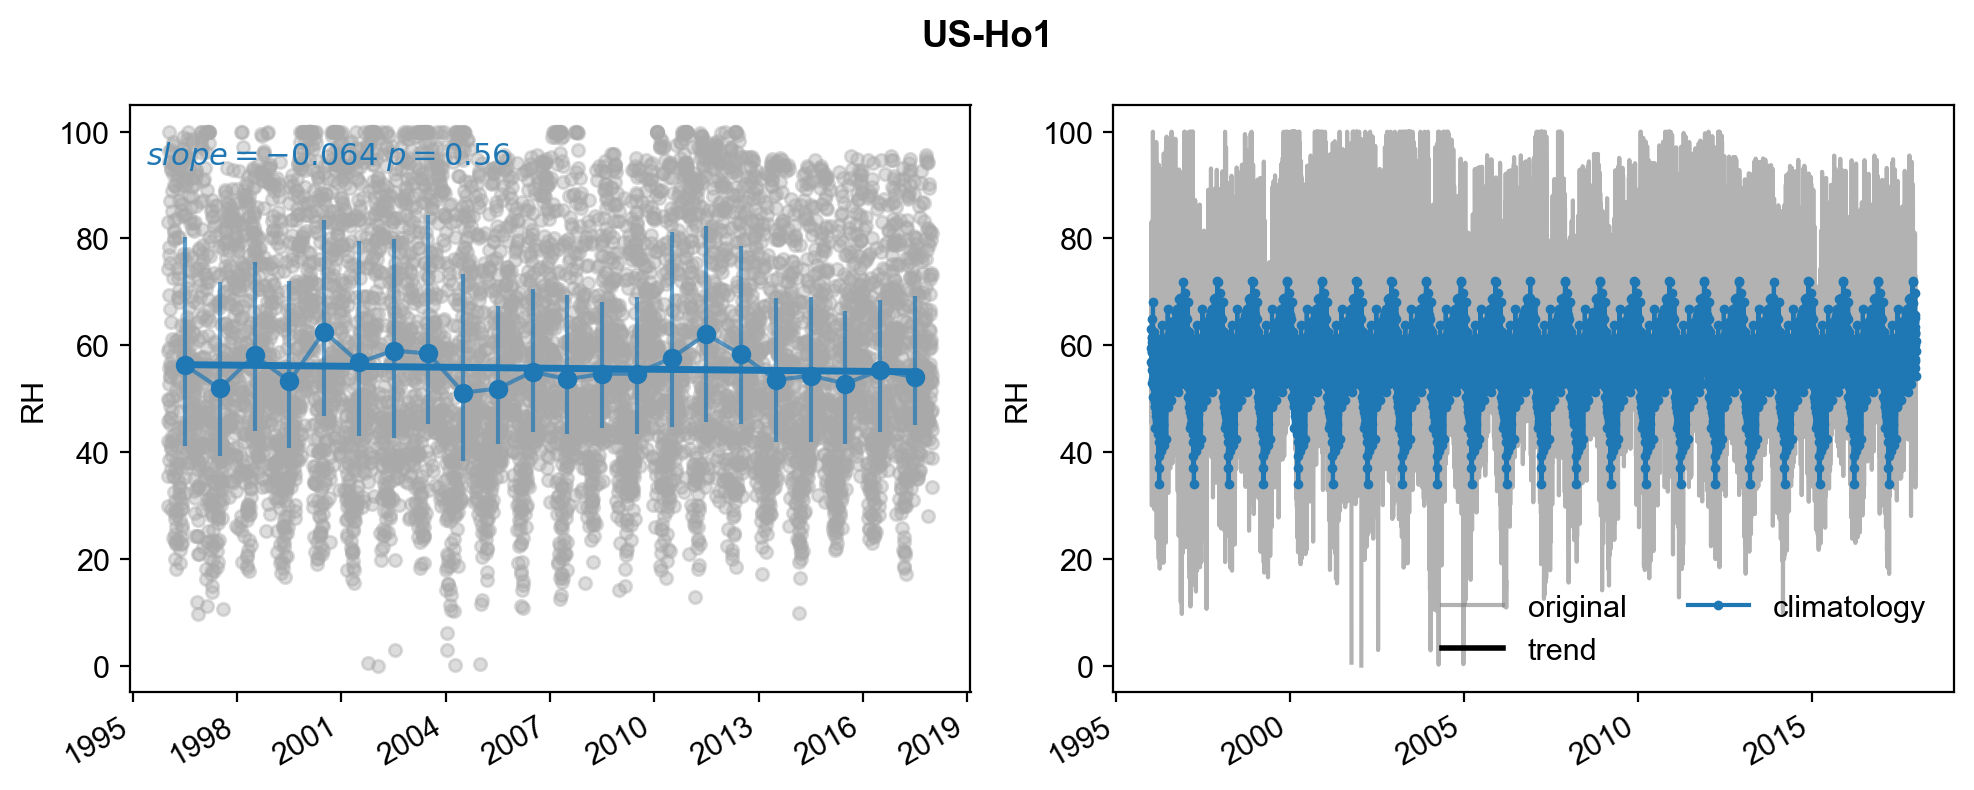

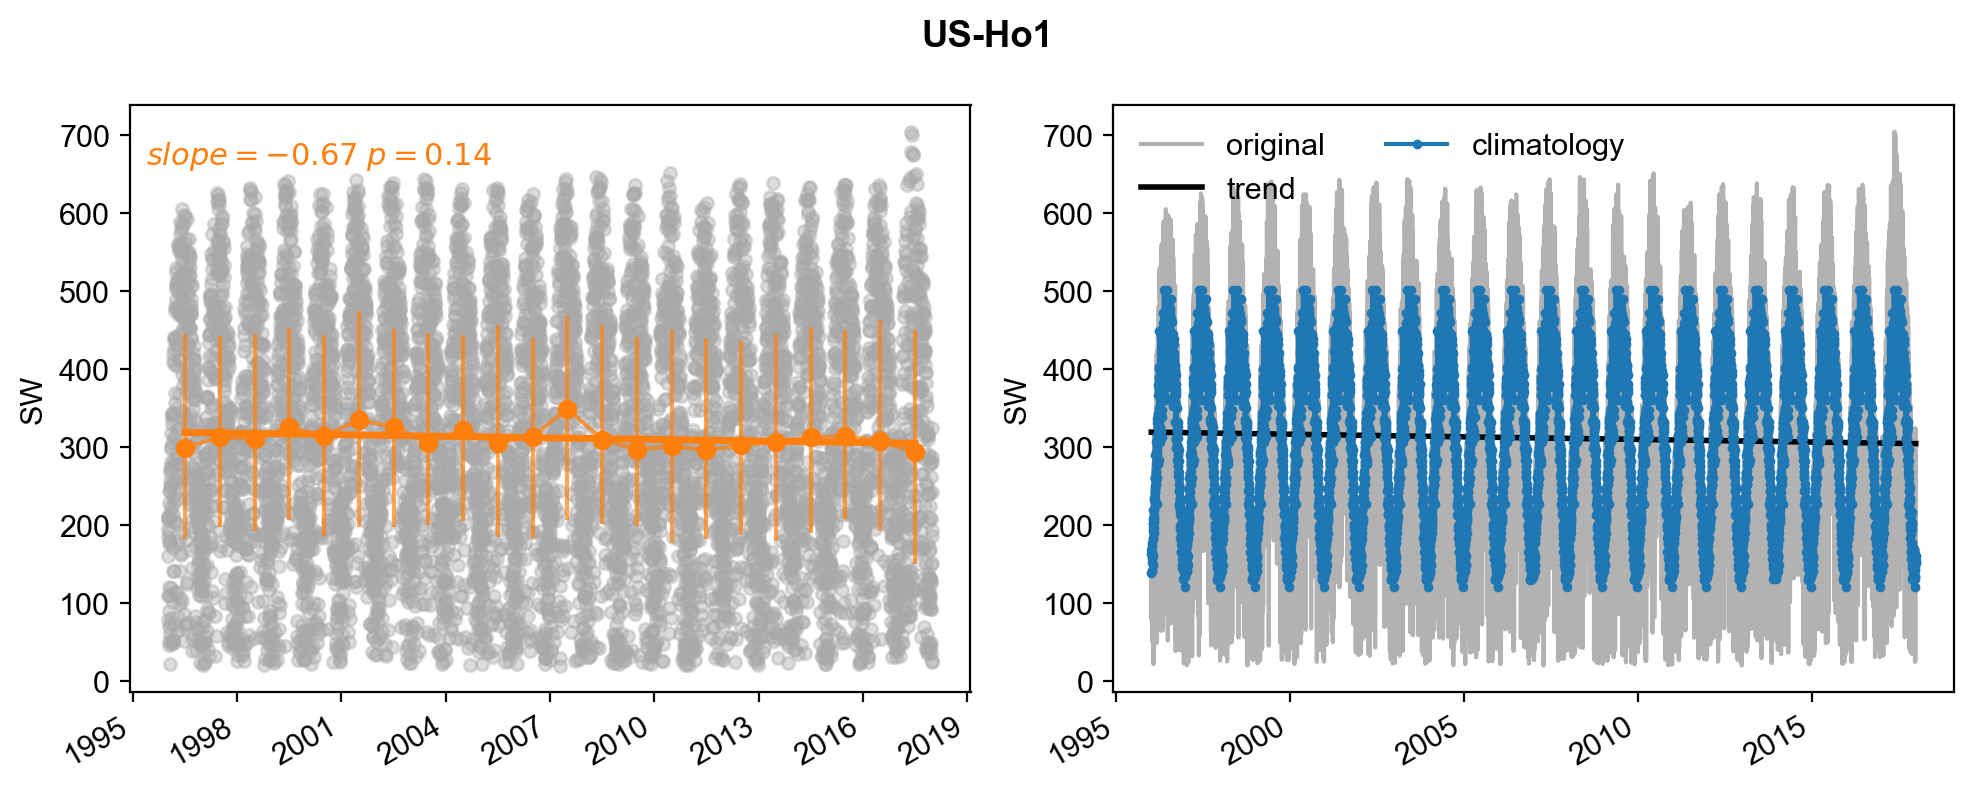

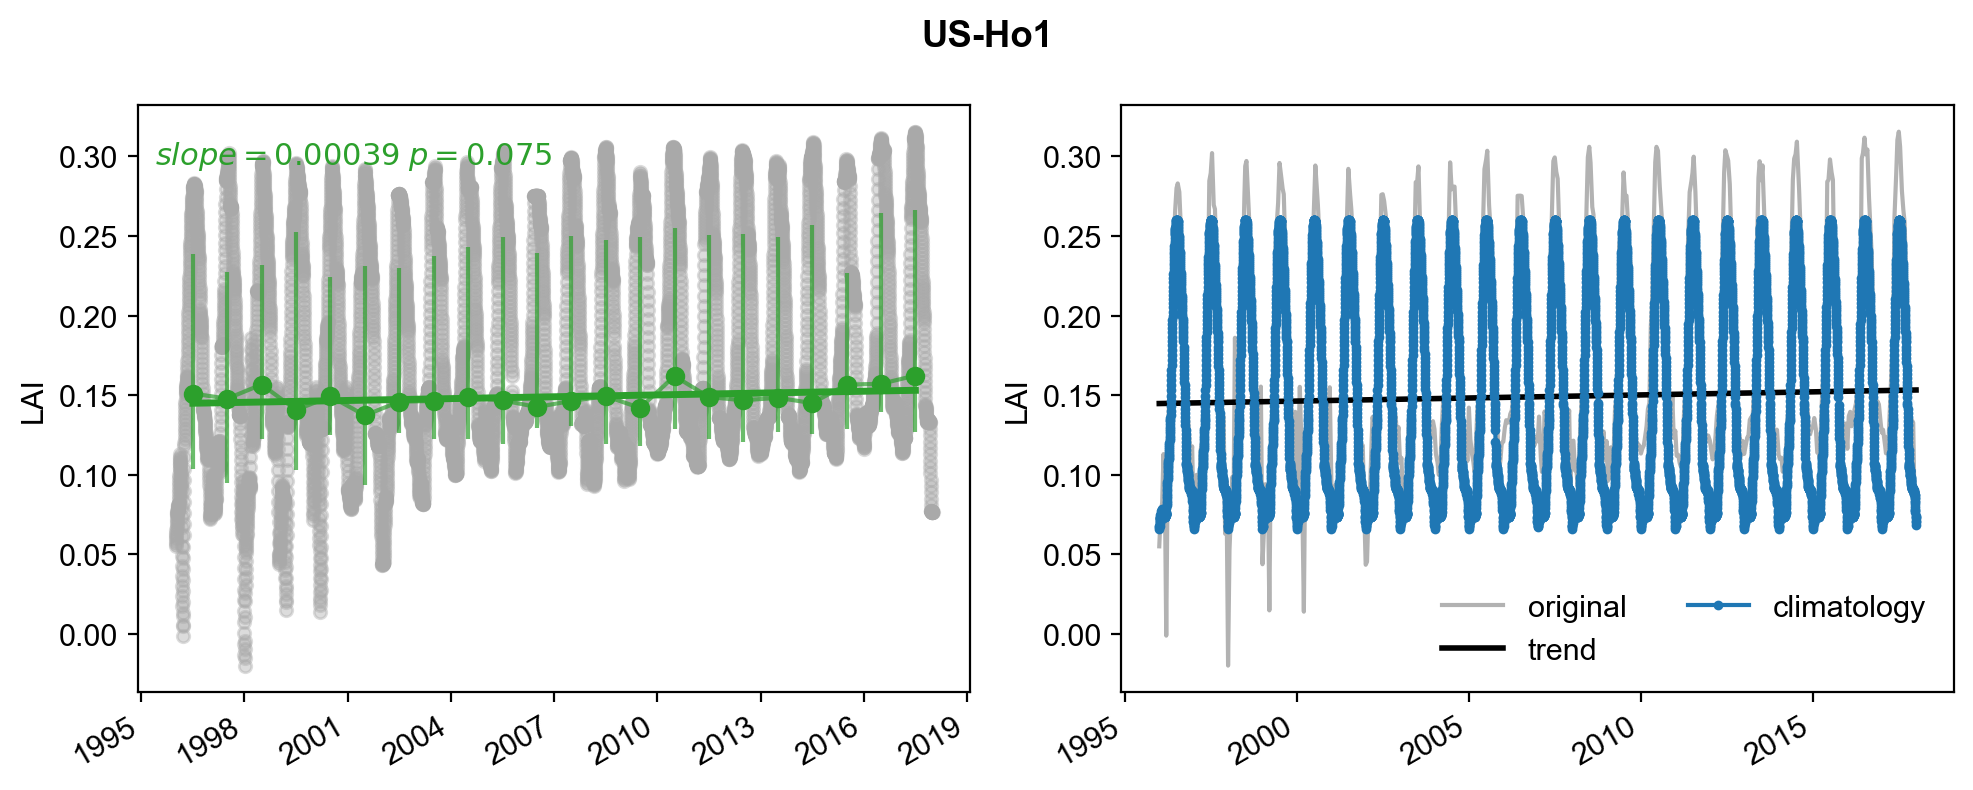

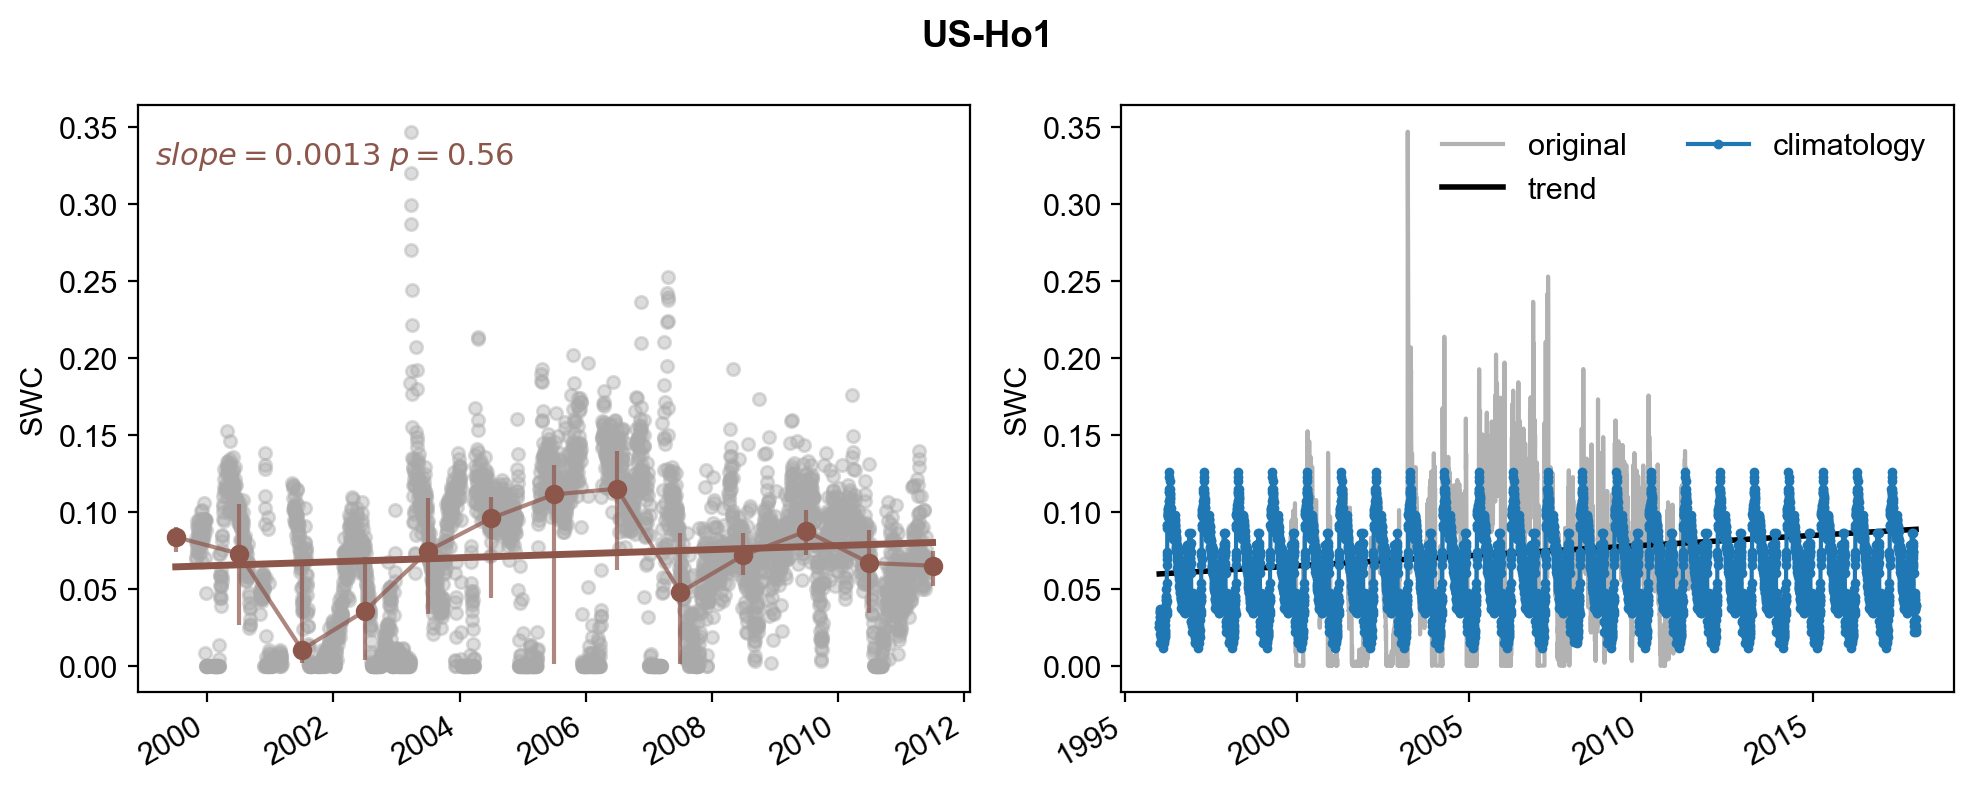

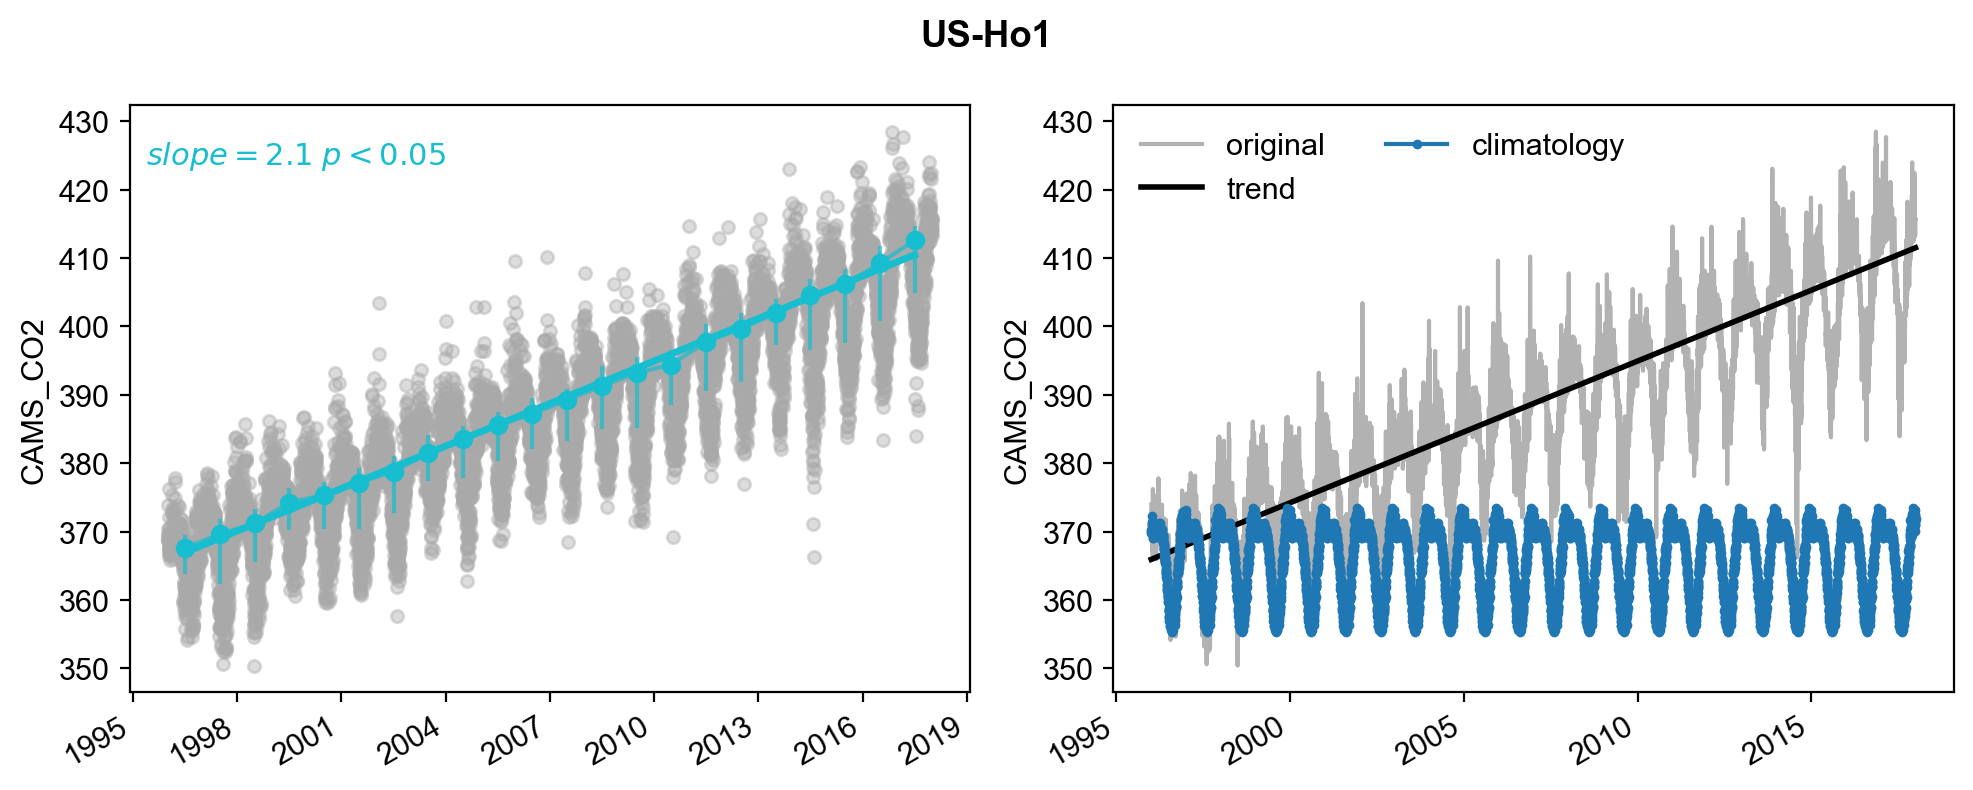

In [6]:
# dictionary to store climatology for each variable
cmt_dic    = {}

vars_trend = ['Tair', 'RH', 'SW', 'LAI', 'SWC', 'CAMS_CO2']
data       = data_full[vars_trend].copy()

stat_dic = {}
columns  = ['slope','intercept','r','p','length']
for var in vars_trend:
    stat_dic[var] = pd.DataFrame(index=[sitecode],columns=columns)
    
# ------------- trend analysis for each variable (whole-year trend) ------------
for var in vars_trend:
    
    fig,axes = plt.subplots(figsize=(10,4),ncols=2)

    # derive the trend
    stat     = check_trend_wholeyear(data,var,fig,axes[0],color=color_dic[var],data_length=True)

    # record stats: slope, intercept, r, p, length(yr)
    stat_dic[var].loc[sitecode,:] = stat
    
    # get the climatology & climatology+trend
    slope     = stat_dic[var].loc[sitecode,'slope'] 
    intercept = stat_dic[var].loc[sitecode,'intercept'] 
    var_cmt   = get_climatology_and_trend(data,var,slope,intercept)
    plot_climatology(var,var_cmt,axes[1])
    cmt_dic[var] = var_cmt

    # edit the figure
    for ax in axes.flat:
        ax.set_ylabel(var)
        plt.setp(ax.get_xticklabels(), rotation=30, horizontalalignment='right')
    fig.suptitle(f'{sitecode}',fontweight='bold')
    plt.tight_layout()

    # break

## Perturbation exps

In [7]:
# color settings
blue_c   ='#0072B2'
green_c  ='#009E73'
brown_c  = '#E69F00'
sblue_c  = '#56B4E9'
pink_c   = '#CC79A7'
yellow_c = '#F0E442'
red_c    = "#311B09"
dark_brown_c = '#8c564b'

color_list = [dark_brown_c,green_c,red_c,pink_c,brown_c,blue_c]
var_color_dic = {}
for k,var in enumerate(['SWC','LAI','Tair','SW',CO2_var,'RH']):
    var_color_dic[var+'_ExpA'] = color_list[k]


iWUE_dic = {'CAMS_CO2_ExpA':sblue_c}
GPP_dic  = {'CAMS_CO2_ExpA':green_c}
Gs_dic   = {'CAMS_CO2_ExpA':brown_c}

target_color_dic = {'iWUE':iWUE_dic,'Gs_linear_mol':Gs_dic,'GPP':GPP_dic}

In [8]:
# variables involved in perturbation 
ctl_vars_par = ['LAI', 'Tair', 'SWC', 'RH', 'SW', 'CAMS_CO2']

# whether to normalize the annual trends (for inter-site comparison)
normalize_para_exp  =  True # False # 
norm_str = 'normalize' if normalize_para_exp else 'unnorm'

## import climatology 
data_cmt   = pd.DataFrame(index=data_full.index,columns=ctl_vars_par)
data_trend = pd.DataFrame(index=data_full.index,columns=ctl_vars_par)

for var in ctl_vars_par:
    var_cmt = cmt_dic[var]
    assert var_cmt.index.equals(data_full.index)
    data_cmt[var]   = var_cmt[var+'_cmt'].values
    data_trend[var] = var_cmt[var+'_withtrend'].values

In [9]:
# data for perturbation analysis:
# growing season + remove nan values in predictors (allow nan in SWC and predictand)
allow_NAN_vars = ['SWC']
noSWC_vars  = [item for item in (predictors+[CO2_var]) if item not in allow_NAN_vars] 
noNAN_index = data_full[noSWC_vars].dropna().index.tolist()

GS_mask     = (data_full['flag_GS_cont_DT']==1)
mask        = GS_mask & (data_full.index.isin(noNAN_index))

data_full   = data_full[mask]
data_cmt   = data_cmt[mask]
data_trend = data_trend[mask]

for var in allow_NAN_vars:
    if var in ctl_vars_par:
        data_cmt[var][data_full[var].isna()]   = np.nan
        data_trend[var][data_full[var].isna()] = np.nan

#----------------- model prediction -----------------
## to save both y_obs & y_pre in different scenarios
df_y = data_full.copy()
df_y = df_y[[target]]

# ----------------- CTL -----------------
X_ctl = data_full[predictors+[CO2_var]]
y_ctl = model_CO2.predict(X_ctl)
X_ctl[target+'_CTL'] = y_ctl
df_y  = df_y.merge(X_ctl[target+'_CTL'],left_index=True,right_index=True,how='left')

# ----------------- mute exps-----------------
for j,var in enumerate(ctl_vars_par):

    X_exp = data_full.copy()
    X_exp = X_exp[predictors+[CO2_var]]
    X_exp[var] = data_cmt[var].values

        
    y_exp  = model_CO2.predict(X_exp)
    exp_ID = var
    y_exp  = pd.DataFrame(y_exp,index=X_exp.index,columns=[target+'_ExpA_'+exp_ID])
    df_y   = df_y.merge(y_exp,left_index=True,right_index=True,how='left')


## plot the results

In [10]:
def regress_annual_noquantile(data_yr,var,ax=None,fig=None,
                              color = 'tab:blue',xy = (0.02,0.9),
                              annotate = True,x_indent=0,
                              data_length=False,anno_str='',
                              legend_label=None,linewidth=2.5,alpha=0.5,s=None):
    
    if (ax is None):
        fig,ax = plt.subplots()
        
    # remove NAN values
    x = data_yr[var].dropna().index.values
    y = data_yr[var].dropna().values
    
    
    x = x+x_indent # indentation of year axis
    ax.scatter(x,y,color=color,alpha=alpha,s=s)
    length = x.shape[0]
    
    # if length < 10 yr, just plot scatters, no line fitting
    if length < 10:
        slope, intercept, r_value, p_value = np.nan, np.nan, np.nan, np.nan
    else:
        slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

        # plot the fitted line
        line  = np.linspace(min(x), max(x), 100)
        y_pre = line*slope+intercept
        ax.plot(line, y_pre,'-',color=color,linewidth=linewidth,label=legend_label)
        
        # annotation
        slope_format = '${:.2g}$' if slope<1 else '${:.2f}$'
        anno_str += ' $slope=$'+slope_format.format(slope)
        if p_value < 0.05:
            anno_str += ' $p<0.05$'
        else:
            anno_str += ' $p=$'+'${:.2g}$'.format(p_value)
        
        if annotate:
            ax.annotate(anno_str,xy=xy, color=color, xycoords='axes fraction')
    
    ax.set_ylabel(var)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # return stats 
    if data_length:
        stat = [slope, intercept, r_value, p_value,length]
    else:
        stat = [slope, intercept, r_value, p_value]
        

    return stat

In [11]:
def check_annualmedian_trend(data_original,var,fig,ax,color,
                             data_length=False,x_indent=0,xy=(0.02,0.9),
                             anno_str='',annotate=True,legend_label=None,
                             normalize=False,linewidth=2.5,alpha=0.5,s=None):
    
    data = data_original.copy()
    data['DOY']       = data.index.dayofyear
    data['Year']      = data.index.year
    data['Year_deci'] = data['DOY']/365.25 + data['Year']
    
    # annual median
    yr_median = data.groupby('Year').median()
    
    # quality control: remove years with incomplete records
    # threshold = average_length - 45days
    yr_count  = data.groupby(data.index.year).count()[var]
    threshold = yr_count[yr_count!=0].mean() - 45
    yr_median[var][yr_count<threshold] = np.nan
    
    # normalize
    if normalize:
        sitemean    = yr_median[var].mean()
        yr_median[var] = (yr_median[var]-sitemean)/sitemean*100
    
    # annual-scale fitting
    # stat: slope, intercept, r_value, p_value (optionally: length,CV)
    stat = regress_annual_noquantile(yr_median,var=var,color=color,fig=fig,ax=ax,
                                     x_indent=x_indent,data_length=data_length,xy=xy,anno_str=anno_str,
                                     annotate=annotate,legend_label=legend_label,
                                     linewidth=linewidth,alpha=alpha,s=s)
    
    
    # set the y_range of the figure
    y_min,y_max = yr_median[var].min(),yr_median[var].max()
    
    return stat,y_min,y_max, yr_median[var]



def check_annualsum_trend(data_original,var,fig,ax,color,data_climate,
                          data_length=False,
                          GPP_unit_convert=False,
                          LE_unit_convert=False,
                          x_indent=0,xy=(0.02,0.9),
                          anno_str='',annotate=True,legend_label=None,
                          normalize=False,linewidth=2.5,alpha=0.5,s=None):
    
    data = data_original.copy()
    data['DOY']       = data.index.dayofyear
    data['Year']      = data.index.year
    data['Year_deci'] = data['DOY']/365.25 + data['Year']
    
    assert data.index.equals(data_climate.index)
    data['Tair']      = data_climate['Tair'].values
    data['daytime_length'] = data_climate['daytime_length'].values

    # GPP unit conversion: umol m-2 s-1 --> gC m-2 day-1
    if GPP_unit_convert:
        data[var] = data[var]*(10**(-6))*12*(data['daytime_length']*3600)
    
    # LE unit conversion: W/m2 --> mm day-1 (or kgH2O m-2 day-1)
    if LE_unit_convert:
        Lv        = 1e+6*(2.501-(2.361e-3)*data['Tair']) # Latent heat of vaporization (J/kg)
        data[var] = data[var]/Lv # unit: kg water m-2 s-1, which is equivalent to mm s-1
        data[var] = data[var]*3600*data['daytime_length'] # unit: kg water m-2 day-1, which is equivalent to mm day-1
        
    # annual sum: gC m-2 yr-1
    yr_sum = data.groupby('Year').sum()
    
    # quality control: remove years with incomplete records
    # threshold = average_length - 45days
    yr_count  = data.groupby(data.index.year).count()[var]
    threshold = yr_count[yr_count!=0].mean() - 45
    yr_sum[var][yr_count<threshold] = np.nan
    
    # normalize
    if normalize:
        sitemean    = yr_sum[var].mean()
        yr_sum[var] = (yr_sum[var]-sitemean)/sitemean*100
    
    # annual-scale fitting
    # stat: slope, intercept, r_value, p_value (optionally: length,CV)
    stat = regress_annual_noquantile(yr_sum,var=var,color=color,fig=fig,ax=ax,
                                     x_indent=x_indent,
                                     data_length=data_length,xy=xy,anno_str=anno_str,
                                     annotate=annotate,legend_label=legend_label,
                                     linewidth=linewidth,alpha=alpha,s=s)
    
    
    # set the y_range of the figure
    y_min,y_max = yr_sum[var].min(),yr_sum[var].max()
    
    return stat,y_min,y_max, yr_sum[var]


In [12]:
def perturbation_method_analysis_plot(df_y,target,var,df_stat,fig,ax,data_climate,
                                      normalize,annual_sum=False,alpha=0.3,s=70):

    # whether to convert the unit 
    GPP_unit_convert = True if target=='GPP' else False
    LE_unit_convert  = True if target=='LE' else False
    

    xy1,xy2 = (0.02,0.92), (0.02,0.68)

    c_ctl  = 'black'
    c_mute = '#56B4E9'

    # conduct & plot the CTL & mute experiments
    if annual_sum: # annual sum
        stat_ctl,y_min_ctl,y_max_ctl, yr_ctl = check_annualsum_trend(df_y,target+'_CTL',fig,ax,
                                                             c_ctl,data_climate,
                                                             data_length=True,
                                                             GPP_unit_convert=GPP_unit_convert,
                                                             LE_unit_convert=LE_unit_convert,
                                                             xy=xy1,
                                                             anno_str='CTL: ',normalize=normalize,
                                                             annotate=False,
                                                             linewidth=4,alpha=alpha,s=s,legend_label='Control')


        stat_ExpA,y_min_ExpA,y_max_ExpA, yr_exp_A = check_annualsum_trend(df_y,'_'.join([target,'ExpA',var]),fig,ax,
                                                                c_mute,data_climate,
                                                                data_length=True,
                                                                GPP_unit_convert=GPP_unit_convert,
                                                                LE_unit_convert=LE_unit_convert,
                                                                xy=xy2,
                                                                anno_str=f'ExpA ({var}): ',
                                                                normalize=normalize,annotate=False,
                                                                linewidth=4,alpha=alpha,s=s,legend_label='mute CO$_2$')

    else: # annual median
        stat_ctl,y_min_ctl,y_max_ctl, yr_ctl = check_annualmedian_trend(df_y,target+'_CTL',fig,ax,c_ctl,
                                                                data_length=True,
                                                                xy=xy1,anno_str='CTL: ',
                                                                normalize=normalize,annotate=False,
                                                                linewidth=4,alpha=alpha,s=s,legend_label='Control')

        stat_ExpA,y_min_ExpA,y_max_ExpA, yr_exp_A = check_annualmedian_trend(df_y,'_'.join([target,'ExpA',var]),fig,ax,
                                                                   c_mute,
                                                                   data_length=True,
                                                                   xy=xy2,anno_str=f'ExpA ({var}): ',
                                                                   normalize=normalize,annotate=False,
                                                                   linewidth=4,alpha=alpha,s=s,legend_label='mute CO$_2$')

    df_stat.loc[target+'_CTL',:]                 = stat_ctl[0],stat_ctl[3],stat_ctl[-1],stat_ctl[-2]
    df_stat.loc['_'.join([target,'ExpA',var]),:] = stat_ExpA[0],stat_ExpA[3],stat_ExpA[-1],stat_ExpA[-2]

    # set y limit & ylabel
    y_min = np.nanmin([y_min_ctl,y_min_ExpA])
    y_max = np.nanmax([y_max_ctl,y_max_ExpA])
    
    ax.set_ylim([y_min-0.1*y_max,y_max+0.1*y_max])

                                  
    return df_stat, yr_ctl, yr_exp_A




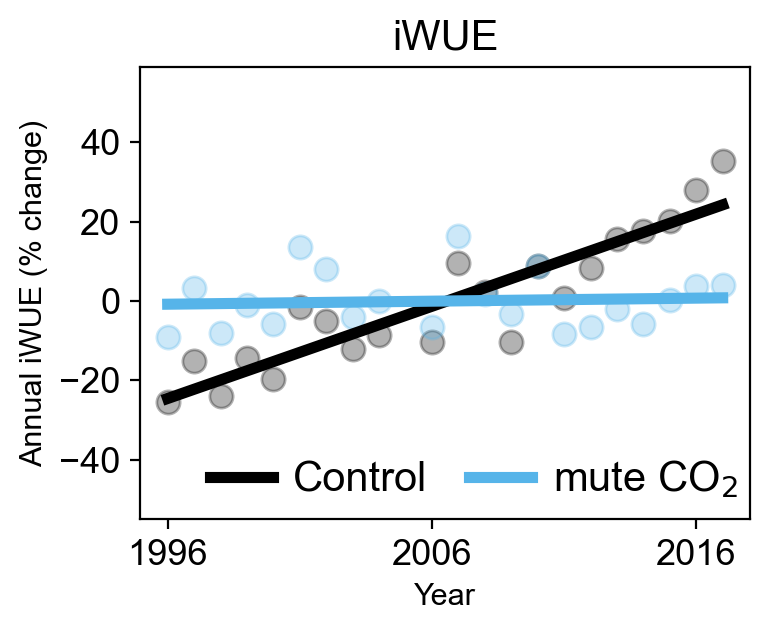

In [13]:
df_stat  = pd.DataFrame(index=df_y.columns[1:],columns=['slope','pvalue','CV','length'])
df_slope_CV_diff = pd.DataFrame()

annual_unit = 'umol C/mol H2O' # iWUE unit
norm_unit   = f'% change'
annual_sum  = False # whether to use annual sum or annual median

fig,ax   = plt.subplots(figsize=(4,3.3))

var = 'CAMS_CO2'
df_stat,yr_ctl,yr_exp_A = perturbation_method_analysis_plot(df_y,target,var,df_stat,fig,ax,
                                                            data_climate=data_full,annual_sum=annual_sum,
                                                            normalize=normalize_para_exp,alpha=0.3)  
ax.set_ylabel(f'{target} ({normalize_para_exp*norm_unit + (not normalize_para_exp)*annual_unit})')
ax.legend(ncols=2,bbox_to_anchor=(1.04, -0.04),loc='lower right',
          fontsize=15,handletextpad=0.5,columnspacing=1.,handlelength=1.5)

df_slope_CV_diff.loc['_'.join(['CTL','minus','ExpA',var]),'slope'] = df_stat.loc[target+'_CTL','slope'] - \
                                                                     df_stat.loc[target+'_ExpA_'+var,'slope']
    
ax.set_ylim([-55,59])
ax.set_xlabel('Year')
ax.set_ylabel(f'Annual {target} (% change)')
ax.set_title(f'{target}',fontsize=15)
ax.tick_params(labelsize=13)
ax.set_xticks(np.arange(df_y.index.year[0],df_y.index.year[-1]+2,10))

plt.tight_layout()